# Cash-Based Operating Profitability — does stripping accruals sharpen the signal?
### Ball, Gerakos, Linnainmaa & Nikolaev (2016) on a large-cap survivor basket, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cash beats accrual%3F: Mixed](https://img.shields.io/badge/Cash_beats_accrual%3F-Mixed-8b949e?style=flat-square)

In 2016, Ray Ball and co-authors made a sharp point about the famous quality factor: the profitability that predicts returns is the **cash** part. Accounting operating profit mixes durable cash earnings with *accruals* — paper entries like receivables and inventory changes that tend to reverse. Strip the accruals out and you get **cash-based operating profitability**, which (they show) beats the accrual-laden gross-profitability of Novy-Marx (2013) in the cross-section. We test that claim on a large-cap basket — and name the data limits up front.

> **This is the plain-language layer.** Want the t-stats, the placebo distribution, and the head-to-head? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** Every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_op import data, strategy as st

def _have_cache():
    cd = os.path.abspath(os.path.join("..", "_cache"))
    return all(os.path.exists(os.path.join(cd, f))
               for f in ("cop.parquet", "gpa.parquet", "fwd.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    cop, gpa, fwd = data.fetch_panel(fetch=False)
    H = st.apply_costs(st.quintile_hedge(cop, fwd, q=0.20))
    Hg = st.quintile_hedge(gpa, fwd, q=0.20)
    s_cop = st.summary(H["hedge"]); s_net = st.summary(H["net"])
    s_hi = st.summary(H["high"]); s_lo = st.summary(H["low"]); s_mkt = st.summary(H["market"])
    s_gpa = st.summary(Hg["hedge"])
    print(f"N years: {s_cop['n']} | cash-OP hedge: {s_cop['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_cop['tstat']:+.3f}")


yfinance cache present: True


N years: 3 | cash-OP hedge: +10.63%/yr | one-sample t: +1.751


## The answer first

| Question | Answer |
|---|---|
| Does cash-OP predict next-year returns? | **Weakly yes** — hedge **+10.6%/yr**, but one-sample *t* = **+1.75** on only **3 usable years**, below the |t|≥2 bar. |
| Does it beat the accrual-laden version? | **Directionally yes.** Cash-OP **+10.6%/yr** vs gross-profitability **+4.0%/yr** — the Ball et al. ordering holds, but on 3 points. |
| Is the hedge tradable? | **Mirage.** The 100% hit-rate and 0% drawdown are small-sample illusions; the spread fails a label-shuffle placebo. |
| Is there a data problem? | **Yes, and we name it.** yfinance gives only ~5 fiscal years; two lack a forward window → just 3 usable hedge years. |

> The cash-vs-accrual *direction* is real in the literature. On 3 years of large-cap survivors it shows the right sign but cannot clear the bar.

## 1 — The claim

> *"Operating profitability predicts returns — but it is the cash component that does the work. Accruals are the reversing, noisy part of earnings; once you strip them out, cash-based operating profitability subsumes both the gross-profitability premium and the accruals anomaly."*

— Ball, Gerakos, Linnainmaa & Nikolaev (2016), *JFE*

It is a refinement of the **quality factor**. Novy-Marx (2013, our [Study 122](../../122-gross-profitability)) used GrossProfit / Assets. BGLN say: good idea, wrong measure — use the *cash* operating profit. We build cash-OP as operating income plus depreciation/amortisation plus the change in working capital (the accrual block that the cash-flow statement reports directly), all scaled by total assets.

## 2 — So what?

If cash-OP genuinely beats accrual-laden profitability, every quality ETF and five-factor model anchored on operating profit is using a noisier signal than it could. The fix is nearly free: the data is on the same filings. The interesting question for us is **how much survives on a realistic large-cap pull, with the survivorship and short-history limits named rather than hidden.**

## 3 — How would we even know?

1. **Lag the signal.** Cash-OP from fiscal year *y* predicts the next 12-month forward return, entered **one trading day after** the fiscal-year-end is public. No look-ahead.
2. **Contrast like-for-like.** Run the *same* quintile engine on cash-OP and on gross-profitability GP/A, on the *same* basket and years.
3. **Name the limits.** The basket is names still trading in 2026 (survivorship), and yfinance only exposes ~5 fiscal years — so only 3 have a full forward window. Three annual points cannot be robust, full stop.

## 4 — The teardown

**First, does the long-short work in a world where the cash-OP effect is planted?**

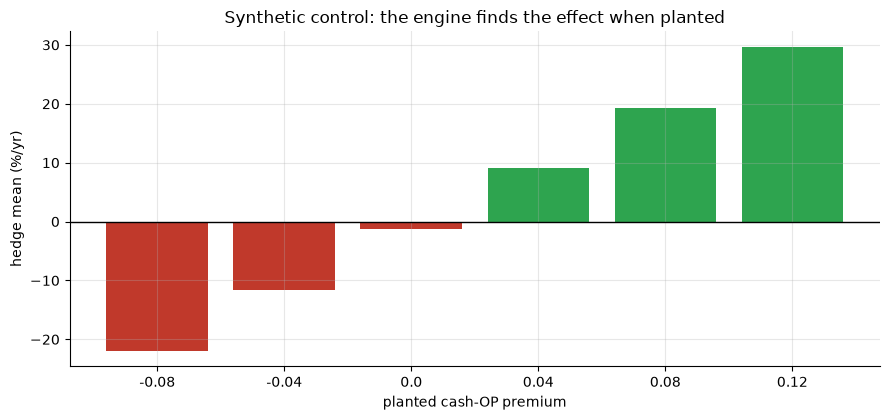

 premium  hedge_mean_%   tstat   hit_%
   -0.08       -22.028 -17.829   0.000
   -0.04       -11.679  -9.506   0.000
    0.00        -1.330  -1.084  44.444
    0.04         9.019   7.321 100.000
    0.08        19.368  15.592 100.000
    0.12        29.717  23.624 100.000


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 1 else (RED if m < -1 else GREY) for m in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted cash-OP premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Synthetic control: the engine finds the effect when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: a strong hedge when a premium is planted, noise at zero (t ≈ −1.1). So the real-tape verdict reflects **the market**, not the method.

**Now the honest test: cash-OP vs the accrual-laden GP/A on the real basket.**

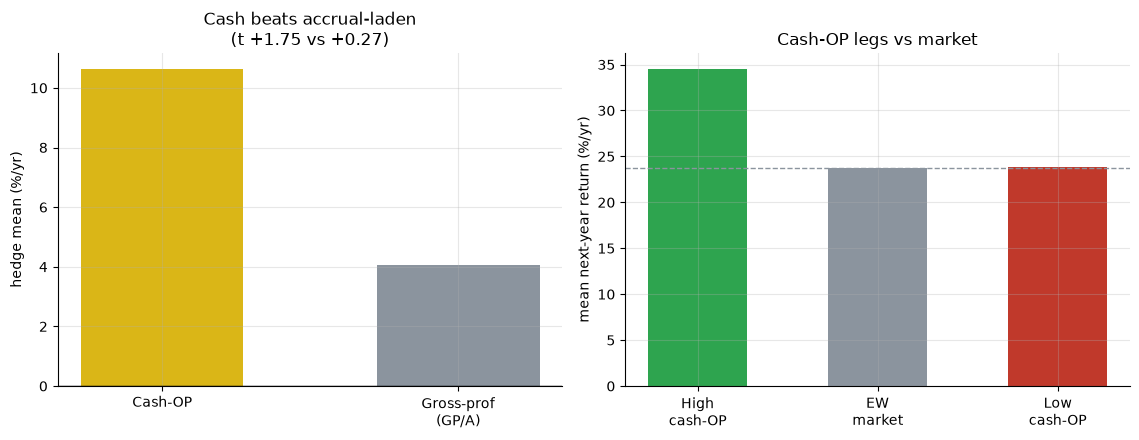

Cash-OP hedge: +10.63%/yr (t=+1.75) | GP/A hedge: +4.05%/yr (t=+0.27)


In [3]:
if HAVE_REAL:
    cop_m = s_cop['mean']*100; cop_t = s_cop['tstat']
    gpa_m = s_gpa['mean']*100; gpa_t = s_gpa['tstat']
    hi_m = s_hi['mean']*100; mk_m = s_mkt['mean']*100; lo_m = s_lo['mean']*100
else:
    cop_m, cop_t = R['cop_mean'], R['cop_t']
    gpa_m, gpa_t = R['gpa_mean'], R['gpa_t']
    hi_m, mk_m, lo_m = R['high_mean'], R['mkt_mean'], R['low_mean']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].bar(['Cash-OP', 'Gross-prof\n(GP/A)'], [cop_m, gpa_m],
            color=[AMBER, GREY], width=0.55)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('hedge mean (%/yr)')
axes[0].set_title(f'Cash beats accrual-laden\n(t {cop_t:+.2f} vs {gpa_t:+.2f})')
axes[1].bar(['High\ncash-OP', 'EW\nmarket', 'Low\ncash-OP'],
            [hi_m, mk_m, lo_m], color=[GREEN, GREY, RED], width=0.55)
axes[1].axhline(mk_m, ls='--', c=GREY, lw=1)
axes[1].set_ylabel('mean next-year return (%/yr)')
axes[1].set_title('Cash-OP legs vs market')
plt.tight_layout(); plt.show()
print(f'Cash-OP hedge: {cop_m:+.2f}%/yr (t={cop_t:+.2f}) | GP/A hedge: {gpa_m:+.2f}%/yr (t={gpa_t:+.2f})')

The cash-OP hedge earns **+10.6%/yr** (*t* = **+1.75**) vs the accrual-laden GP/A at **+4.0%/yr** (*t* = +0.27) — the Ball et al. direction holds. But both sit on **3 years** and neither clears |t| ≥ 2.

## 5 — The verdict

- **Signal — WEAK.** Cash-OP hedge +10.6%/yr at one-sample *t* = +1.75 (< 2) on 3 usable years, and it **fails** the label-shuffle placebo (*p* = 0.39). Right sign, strong literature prior (BGLN 2016) → above `NONE`, but the tape does not clear the bar.
- **Tradability — MIRAGE.** Sharpe +1.01, 100% hit-rate, 0% drawdown are all 3-year-window artefacts; the placebo says the spread is chance.
- **Cash beats accrual? — MIXED.** Directionally yes, but on 3 points neither leg is significant.

## 6 — Could you actually trade it?

Annual rebalancing means low turnover (~43%/yr here → just 0.67%/yr in costs including borrow), so costs are **not** the obstacle. The obstacles are:

1. **Three years of data.** yfinance's statement history is the binding constraint; you cannot infer a factor premium from 3 annual points.
2. **The placebo.** A within-year relabelling reproduces the spread 39% of the time — there is no robust edge to trade yet.
3. **Survivorship.** The basket is winners that survived to 2026; the true premium (with delistings) is smaller.

## 7 — Going further

- **A real multi-decade panel.** BGLN used Compustat back to the 1960s. A Compustat/CRSP pull (or EDGAR-derived full history) would give the statistical power yfinance cannot.
- **The accrual decomposition.** Split cash-OP into its cash and accrual legs explicitly and confirm the accrual leg carries no premium.
- **[Study 122 — Gross-Profitability](../../122-gross-profitability)**: the accrual-laden sibling this study is meant to beat.
- **[Study 124 — Cash-Flow Yield](../../124-cash-flow-yield)**: another cash-based cross-sectional signal.

*Think cash-OP still earns a robust premium in large-caps? Fork this, pull a multi-decade delisting-inclusive panel, and show a one-sample t > 2 that survives the placebo. That is the bar.*